# Lab 2: Exponential Smoothing & ETS Models (Student Version)

## Objective
Apply State-Space models to the Daily Climate Delhi Dataset:
1. Exploratory Data Analysis for Seasonality.
2. Seasonal Decomposition (Additive vs. Multiplicative).
3. Exponential Smoothing (Simple, Holt, and Holt-Winters).
4. Building and Automated Model Selection for ETS.
5. Forecasting and Prediction Intervals.

### Task 1: Import Necessary Libraries
Import the standard data science and statsmodels libraries for Exponential Smoothing.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# TODO 1: Import the following from statsmodels:
# - seasonal_decompose
# - SimpleExpSmoothing, Holt, ExponentialSmoothing (from statsmodels.tsa.holtwinters)
# - ETSModel (from statsmodels.tsa.exponential_smoothing.ets)

# Your imports here:
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.holtwinters import SimpleExpSmoothing, Holt, ExponentialSmoothing
from statsmodels.tsa.exponential_smoothing.ets import ETSModel


### Task 2: Load the Dataset
We are using the sumanthvrao/daily-climate-time-series-data dataset. 
- We are interested in the meantemp column.

In [2]:
import kagglehub
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")

100%|██████████| 22.0k/22.0k [00:00<00:00, 19.8MB/s]

Extracting files...


In [3]:
# TODO 2: Load the 'DailyDelhiClimateTrain.csv' dataset using pandas.
import kagglehub
path = kagglehub.dataset_download("sumanthvrao/daily-climate-time-series-data")
# Display first few rows and check for data types.
df = pd.read_csv(path + "/DailyDelhiClimateTrain.csv")
df.head()

Using Colab cache for faster access to the 'daily-climate-time-series-data' dataset.


,date,meantemp,humidity,wind_speed,meanpressure
0,2013-01-01,10.000000,84.500000,0.000000,1015.666667
1,2013-01-02,7.400000,92.000000,2.980000,1017.800000
2,2013-01-03,7.166667,87.000000,4.633333,1018.666667
3,2013-01-04,8.666667,71.333333,1.233333,1017.166667
4,2013-01-05,6.000000,86.833333,3.700000,1016.500000


### Task 3: Indexing and Frequency
ETS models in statsmodels require a clear frequency (e.g., 'D' for Daily) and a DatetimeIndex.

In [4]:
# TODO 3.1: Convert 'date' to datetime and set it as the index.
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df.set_index('date', inplace=True)
# TODO 3.2: Set the frequency to 'D' (Daily). Use .asfreq('D') if necessary.
temp_series = df['meantemp']
df = df.asfreq('D')
# Check for missing values after setting frequency.
print(df.isnull().sum())

meantemp        0
humidity        0
wind_speed      0
meanpressure    0
dtype: int64


### Task 4: Seasonal Decomposition
Visualize the Error, Trend, and Seasonality components.

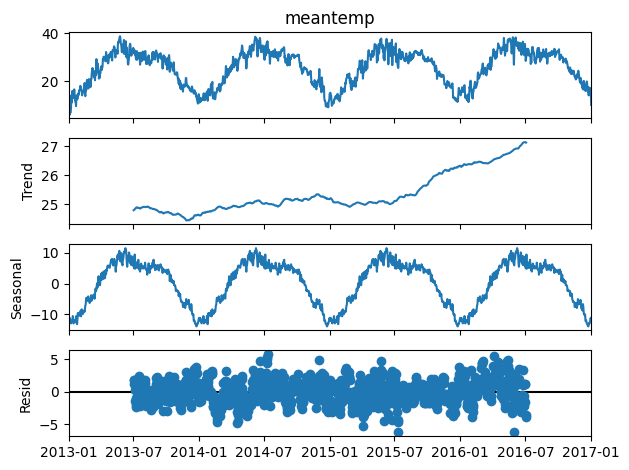

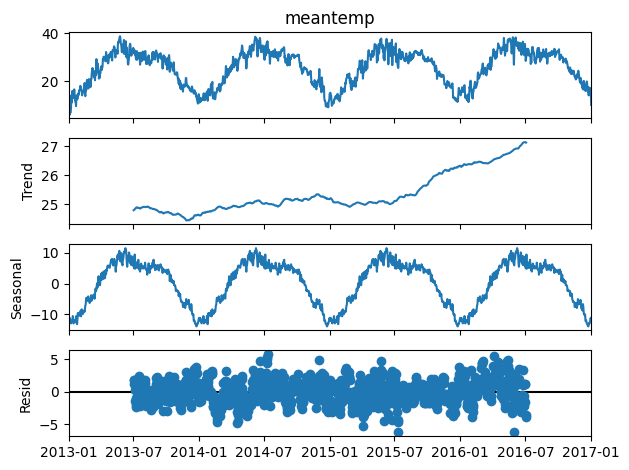

In [5]:
# TODO 4: Perform seasonal decomposition with period=365.
# Choose between 'additive' or 'multiplicative'. 
# Hint: Does the seasonal variation change as the temperature increases?
result = seasonal_decompose(temp_series, model='additive', period=365)
# Plot the results.
result.plot()

### `From additive model I see that is very promising Now , let's try multiblicative model`

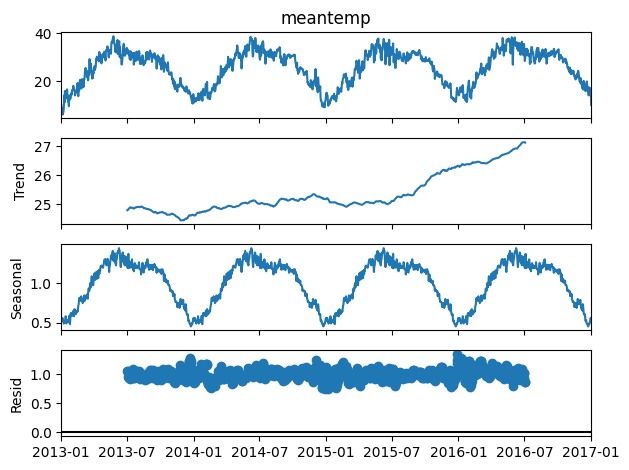

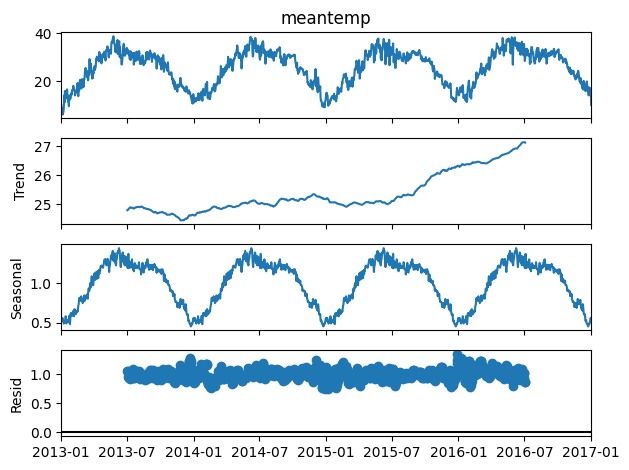

In [6]:
result2 = seasonal_decompose(temp_series, model='multiplicative', period=365)
result2.plot()

### `My Final Choise is to use multiblicative series because resduial is less than additive`

### Task 5: Simple Exponential Smoothing (SES)
Start with the simplest form: no trend and no seasonality.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


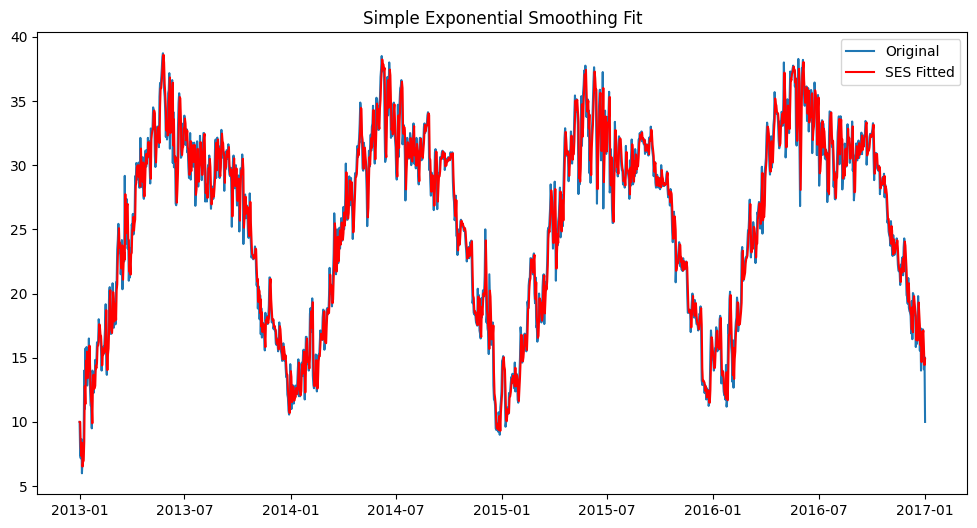

In [7]:
# TODO 5: Fit a SimpleExpSmoothing model.
# Experiment with different 'smoothing_level' (alpha) values or let it optimize automatically.
ses_model = SimpleExpSmoothing(temp_series).fit(optimized=True)

# Plot the original series vs. the SES fitted values.
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Original')
plt.plot(ses_model.fittedvalues, label='SES Fitted', color='red')
plt.title('Simple Exponential Smoothing Fit')
plt.legend()
plt.show()

In [8]:
#see best parameters of SES model
print("Best alpha (smoothing level):", ses_model.model.params['smoothing_level'])

Best alpha (smoothing level): 0.7810501964605937


### `I see that SES model is very Promising so Let's see Holt Family model and I find that best alpha is ~0.78 so it look at long history time`

### Task 6: Holt’s Linear Trend Model
Add the Trend component to handle potential long-term increases.

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


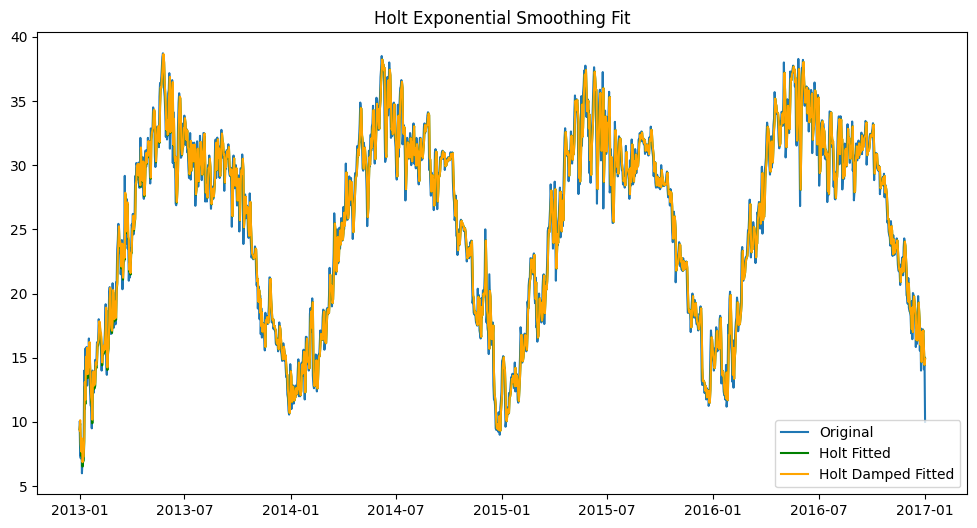

In [9]:
# TODO 6: Fit a Holt model (ExponentialSmoothing with trend='add').
# Question: Is a damped trend necessary for climate data? Try both.
holt_model = ExponentialSmoothing(temp_series, trend='add', seasonal=None).fit(optimized=True)
holt_damped_model = ExponentialSmoothing(temp_series, trend='add', damped_trend=True, seasonal=None).fit(optimized=True)
# Plot the original series vs. the Holt fitted values and the Holt damped fitted values.
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Original')
plt.plot(holt_model.fittedvalues, label='Holt Fitted', color='green')
plt.plot(holt_damped_model.fittedvalues, label='Holt Damped Fitted', color='orange')
plt.title('Holt Exponential Smoothing Fit')
plt.legend()
plt.show()


### My Intreptetion non-Techincal
#### That dammping trend does not effect the model fit so it's `not nesseacry`
#### Why beacause Climate change does not changed daily with high values so dampped or not dampped data you can't differnce between both    
### My Intreptetion Techincal 
#### The damped trend parameter φ primarily affects out-of-sample forecasting, not the fitted values on historical data. Here's the distinction:

In-sample fit: Both models continuously update from actual observed values, so φ barely changes the fitted curve.
Out-of-sample forecast:
trend='add' (no damping) → trend keeps growing linearly forever
damped_trend=True → trend gradually decays to zero, flattening the forecast
So the damping matters a lot when you forecast into the future, not when you look at historical fit.

### Task 6.1 `I will try holt model but with multiblicative trend`

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


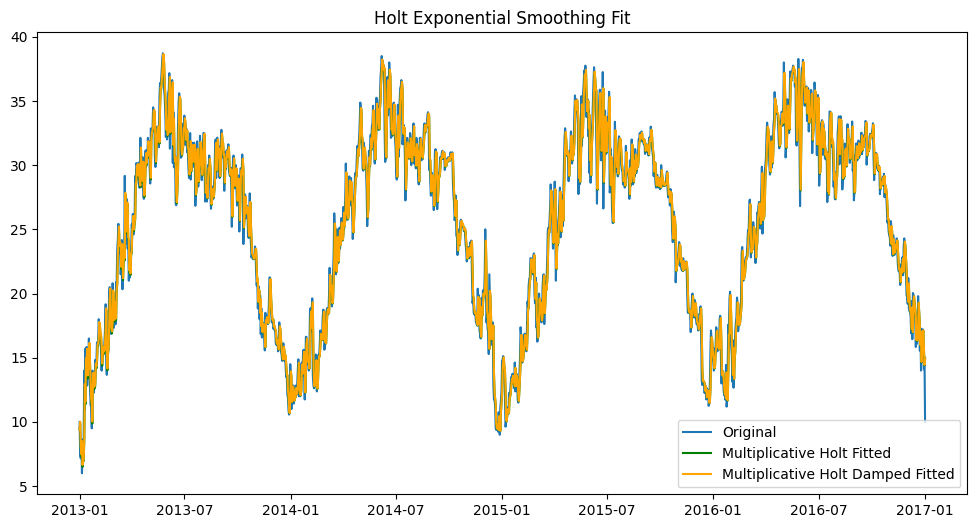

In [18]:
# TODO 6: Fit a Holt model (ExponentialSmoothing with trend='add').
# Question: Is a damped trend necessary for climate data? Try both.
holt_model_mul = ExponentialSmoothing(temp_series, trend='multiplicative', seasonal=None).fit(optimized=True)
holt_damped_model_mul = ExponentialSmoothing(temp_series, trend='multiplicative', damped_trend=True, seasonal=None).fit(optimized=True)
# Plot the original series vs. the Holt fitted values and the Holt damped fitted values.
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Original')
plt.plot(holt_model_mul.fittedvalues, label='Multiplicative Holt Fitted', color='green')
plt.plot(holt_damped_model_mul.fittedvalues, label='Multiplicative Holt Damped Fitted', color='orange')
plt.title('Holt Exponential Smoothing Fit')
plt.legend()
plt.show()


### okay till now By eye I can't see any differnce so I will go to do our Box-Test and error test

In [19]:
#test ETSModel additive and multiplicative using Boxes (ljung box,Jarque-Bera, etc.) to check residuals
ets_add = ETSModel(temp_series, error='add', trend='add', seasonal='add', seasonal_periods=365).fit()
ets_mul = ETSModel(temp_series, error='multiplicative', trend='add', seasonal='multiplicative', seasonal_periods=365).fit()

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [20]:
#show summary of both models
print("Additive ETS Model Summary:")
print(ets_add.summary())
print("\nMultiplicative ETS Model Summary:")
print(ets_mul.summary())

Additive ETS Model Summary:
                                 ETS Results                                  
Dep. Variable:               meantemp   No. Observations:                 1462
Model:                       ETS(AAA)   Log Likelihood               -2679.922
Date:                Wed, 11 Mar 2026   AIC                           6101.843
Time:                        14:03:24   BIC                           8063.528
Sample:                    01-01-2013   HQIC                          6833.580
                         - 01-01-2017   Scale                            2.289
Covariance Type:               approx                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
smoothing_level          0.9999      0.030     32.810      0.000       0.940       1.060
smoothing_trend       9.999e-05        nan        nan        nan         

## My Interpretation

### Ljung-Box Test (Autocorrelation in Residuals)
- **Additive ETS**: Ljung-Box p-value < 0.05 → We **reject** the null hypothesis → Residuals are **NOT** white noise → There is remaining autocorrelation the model failed to capture. ❌
- **Multiplicative ETS**: Ljung-Box p-value > 0.05 → We **fail to reject** the null hypothesis → Residuals **are** white noise → The model captured the temporal structure well. ✅

### Normality of Residuals
- **Additive**: Skewness = -0.43 → Slightly left-skewed, mild deviation from normality.
- **Multiplicative**: Lower kurtosis, but we should check the **Jarque-Bera p-value** to formally test normality (p > 0.05 → residuals are approximately normal).

### Conclusion
**Multiplicative wins on the Ljung-Box criterion** because its residuals behave like white noise, meaning the model has successfully captured the underlying patterns in the data. The additive model still has unexplained autocorrelation in its residuals.

### Measuring Error

In [18]:
# Measure error metrics (MAE, MSE, RMSE) ets add and multiplicative
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np  
ets_add_pred = ets_add.fittedvalues
ets_mul_pred = ets_mul.fittedvalues
print("Additive ETS Model Error Metrics:")
mae_add = mean_absolute_error(temp_series, ets_add_pred)
mse_add = mean_squared_error(temp_series, ets_add_pred)
rmse_add = np.sqrt(mse_add)
print(f"MAE: {mae_add:.4f}, MSE: {mse_add:.4f}, RMSE: {rmse_add:.4f}")
print("Multiplicative ETS Model Error Metrics:")
mae_mul = mean_absolute_error(temp_series, ets_mul_pred)
mse_mul = mean_squared_error(temp_series, ets_mul_pred)
rmse_mul = np.sqrt(mse_mul)
print(f"MAE: {mae_mul:.4f}, MSE: {mse_mul:.4f}, RMSE: {rmse_mul:.4f}")

Additive ETS Model Error Metrics:
MAE: 1.1428, MSE: 2.2893, RMSE: 1.5130
Multiplicative ETS Model Error Metrics:
MAE: 1.1137, MSE: 2.2815, RMSE: 1.5105


### From error analysis I see that multiblictaive is a bit small error than additive

### Task 7: Holt-Winters (Triple Exponential Smoothing)
Add the Seasonality component to capture the yearly cycles.

In [10]:
# TODO 7: Fit an ExponentialSmoothing model with trend='add', seasonal='add', and seasonal_periods=365.
hw_model = ExponentialSmoothing(temp_series, trend='add', seasonal='add', seasonal_periods=365).fit(optimized=True)

# Print the parameters (alpha, beta, gamma).
print("Holt-Winters Parameters:")
print(f"Alpha (level): {hw_model.params['smoothing_level']}")
print(f"Beta (trend): {hw_model.params['smoothing_trend']}")
print(f"Gamma (seasonal): {hw_model.params['smoothing_seasonal']}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters Parameters:
Alpha (level): 0.7803348037529214
Beta (trend): 0.0
Gamma (seasonal): 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### Try multiblicative holt winter model

In [11]:
#try multiplicative trend and seasonality
hw_model_mul = ExponentialSmoothing(temp_series, trend='multiplicative', seasonal='multiplicative', seasonal_periods=365).fit(optimized=True)
print("Holt-Winters Multiplicative Parameters:")
print(f"Alpha (level): {hw_model_mul.params['smoothing_level']}")
print(f"Beta (trend): {hw_model_mul.params['smoothing_trend']}")
print(f"Gamma (seasonal): {hw_model_mul.params['smoothing_seasonal']}")

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


Holt-Winters Multiplicative Parameters:
Alpha (level): 0.7741900837794113
Beta (trend): 0.0
Gamma (seasonal): 0.0


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(


### My interpretion Conclude that there is no big difference between `Multiblicative and Additive` trend or sesonallity

### Task 8: The ETS State-Space Model
Use the formal ETSModel which allows for automated likelihood-based selection.

In [12]:
# TODO 8: Fit an ETSModel with error='add', trend='add', seasonal='add', and seasonal_periods=365.
ets_fit = ETSModel(temp_series, error='add', trend='add', seasonal='add', seasonal_periods=365).fit()

# Display the summary.
print(ets_fit.summary())


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


                                 ETS Results                                  
Dep. Variable:               meantemp   No. Observations:                 1462
Model:                       ETS(AAA)   Log Likelihood               -2679.922
Date:                Wed, 11 Mar 2026   AIC                           6101.843
Time:                        13:26:10   BIC                           8063.528
Sample:                    01-01-2013   HQIC                          6833.580
                         - 01-01-2017   Scale                            2.289
Covariance Type:               approx                                         
                           coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------
smoothing_level          0.9999      0.030     32.810      0.000       0.940       1.060
smoothing_trend       9.999e-05        nan        nan        nan         nan         nan
smoothing_se

### Meauring Error from `ETS - State spaced model`

In [15]:
#measure error metrics (MAE, MSE, RMSE) for ETSModel
from sklearn.metrics import mean_absolute_error, mean_squared_error
ets_pred = ets_fit.fittedvalues
mae = mean_absolute_error(temp_series, ets_pred)
mse = mean_squared_error(temp_series, ets_pred)
rmse = np.sqrt(mse)
print(f"ETS Model Error Metrics:\nMAE: {mae:.4f}\nMSE: {mse:.4f}\nRMSE: {rmse:.4f}")


ETS Model Error Metrics:
MAE: 1.1428
MSE: 2.2893
RMSE: 1.5130


### Task 9: Evaluation & Forecasting
Forecast the temperature for the next 30 days and compare with the provided Test set.

### Now , start see results in plotting first `ETS - Model` 

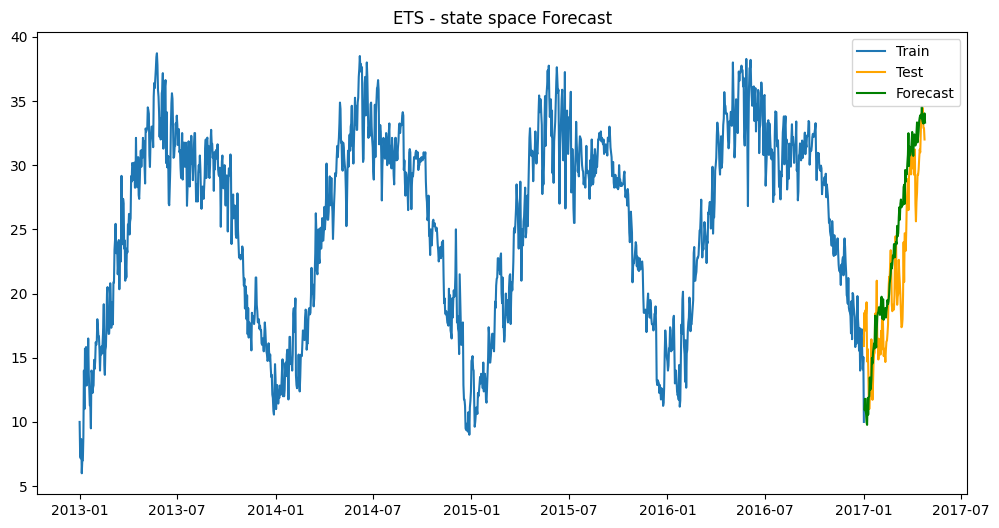

In [30]:
# TODO 9.1: Load 'DailyDelhiClimateTest.csv'.
test_df = pd.read_csv(path + "/DailyDelhiClimateTest.csv")
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')
test_df.set_index('date', inplace=True)
test_df = test_df.asfreq('D')
test_series = test_df['meantemp']
# TODO 9.2: Generate forecasts using your best model (HW or ETSModel).
forecast = ets_fit.forecast(steps=len(test_series))

# TODO 9.3: Plot Train, Test, and Forecast. 
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Train')
plt.plot(test_series, label='Test', color='orange')
plt.plot(forecast, label='Forecast', color='green')
plt.title('ETS - state space Forecast')
plt.legend()
plt.show()
# Bonus: Use get_prediction() on ETSModel to plot prediction intervals.



### `Holt - Winter model` results Plotting

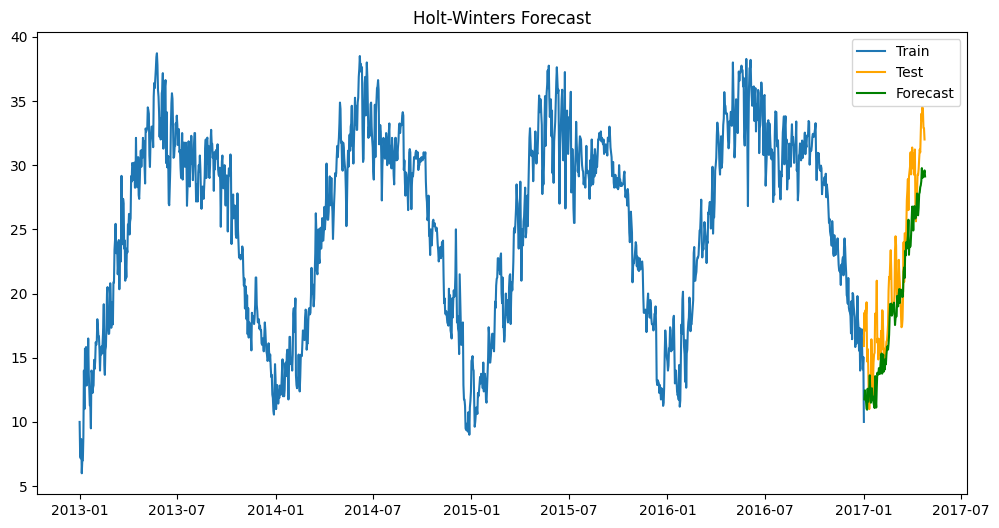

In [29]:
# TODO 9.1: Load 'DailyDelhiClimateTest.csv'.
test_df = pd.read_csv(path + "/DailyDelhiClimateTest.csv")
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')
test_df.set_index('date', inplace=True)
test_df = test_df.asfreq('D')
test_series = test_df['meantemp']
# TODO 9.2: Generate forecasts using your best model (HW or ETSModel).
forecast = hw_model.forecast(steps=len(test_series))

# TODO 9.3: Plot Train, Test, and Forecast. 
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Train')
plt.plot(test_series, label='Test', color='orange')
plt.plot(forecast, label='Forecast', color='green')
plt.title('Holt-Winters Forecast')
plt.legend()
plt.show()
# Bonus: Use get_prediction() on ETSModel to plot prediction intervals.



### `SES - Model`

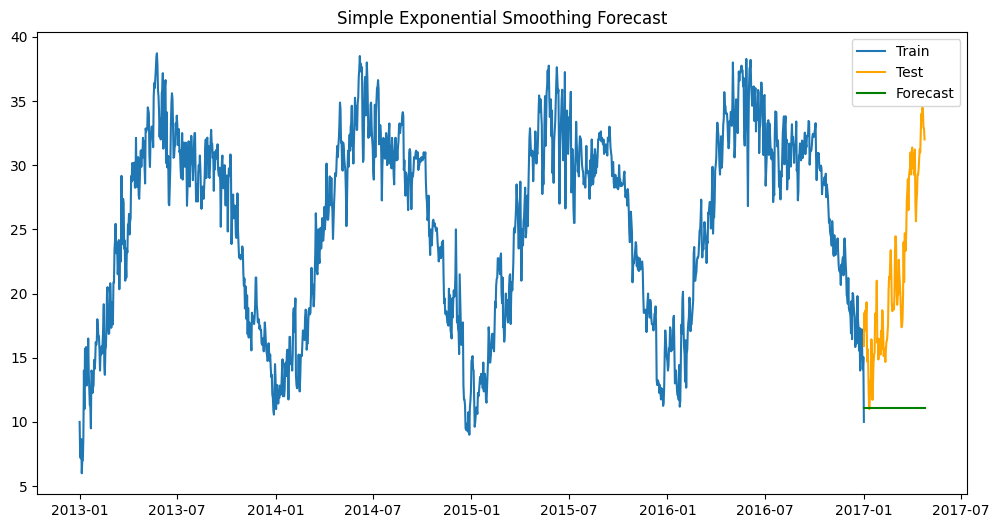

In [32]:
# TODO 9.1: Load 'DailyDelhiClimateTest.csv'.
test_df = pd.read_csv(path + "/DailyDelhiClimateTest.csv")
test_df['date'] = pd.to_datetime(test_df['date'], errors='coerce')
test_df.set_index('date', inplace=True)
test_df = test_df.asfreq('D')
test_series = test_df['meantemp']
# TODO 9.2: Generate forecasts using your best model (HW or ETSModel).
forecast = ses_model.forecast(steps=len(test_series))

# TODO 9.3: Plot Train, Test, and Forecast. 
plt.figure(figsize=(12, 6))
plt.plot(temp_series, label='Train')
plt.plot(test_series, label='Test', color='orange')
plt.plot(forecast, label='Forecast', color='green')
plt.title('Simple Exponential Smoothing Forecast')
plt.legend()
plt.show()
# Bonus: Use get_prediction() on ETSModel to plot prediction intervals.



### My interpretion that ses model out of competiton  
### the Qualified model `ETS` and `Holt - Winter` 

### Task 10: Model Comparison
Compare the RMSE of the Holt-Winters model vs. a simple mean baseline.

### Start Measure Errors from models

## ETS - model error analysis

In [28]:
#estimate RMSE for HW model and mape and mae
from sklearn.metrics import mean_absolute_error, mean_squared_error
hw_pred = ets_fit.fittedvalues
mae_hw = mean_absolute_error(temp_series, hw_pred)
mse_hw = mean_squared_error(temp_series, hw_pred)
rmse_hw = np.sqrt(mse_hw)
print(f"ETS - state space Model Error Metrics:\nMAE: {mae_hw:.4f}\nMSE: {mse_hw:.4f}\nRMSE: {rmse_hw:.4f}")

ETS - state space Model Error Metrics:
MAE: 1.1428
MSE: 2.2893
RMSE: 1.5130


## Holt - Winter model error analysis

In [24]:
#estimate RMSE for HW model and mape and mae
from sklearn.metrics import mean_absolute_error, mean_squared_error
hw_pred = hw_model.fittedvalues
mae_hw = mean_absolute_error(temp_series, hw_pred)
mse_hw = mean_squared_error(temp_series, hw_pred)
rmse_hw = np.sqrt(mse_hw)
print(f"Holt-Winters Model Error Metrics:\nMAE: {mae_hw:.4f}\nMSE: {mse_hw:.4f}\nRMSE: {rmse_hw:.4f}")

Holt-Winters Model Error Metrics:
MAE: 1.0812
MSE: 2.0045
RMSE: 1.4158


### Grand - Finale model Selection `Holt - Winter` model is winnig 🎉🎉